Latihan Pratikum 1

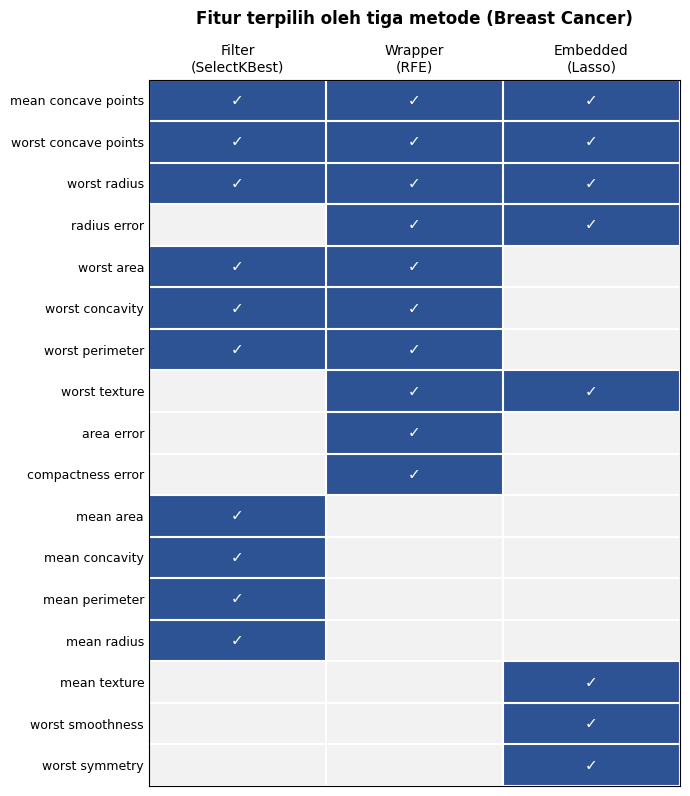

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
names = X.columns
k = 10

skb = SelectKBest(chi2, k=k).fit(MinMaxScaler().fit_transform(X), y)
filter_f = set(names[skb.get_support()])

Xs = StandardScaler().fit_transform(X)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=k).fit(Xs, y)
wrapper_f = set(names[rfe.support_])

sfm = SelectFromModel(Lasso(alpha=0.02), max_features=k, threshold=1e-5).fit(Xs, y)
embedded_f = set(names[sfm.get_support()])

# Urutkan fitur: yang dipilih paling banyak metode ada di atas
allf = sorted(filter_f | wrapper_f | embedded_f,
              key=lambda f: (-((f in filter_f) + (f in wrapper_f) + (f in embedded_f)), f))
M = np.array([[f in filter_f, f in wrapper_f, f in embedded_f] for f in allf]).astype(int)

fig, ax = plt.subplots(figsize=(7, 0.38 * len(allf) + 1.6))
ax.imshow(M, cmap=ListedColormap(["#F2F2F2", "#2E5395"]), aspect="auto")
ax.set_xticks(range(3))
ax.set_xticklabels(["Filter\n(SelectKBest)", "Wrapper\n(RFE)", "Embedded\n(Lasso)"])
ax.xaxis.tick_top()
ax.set_yticks(range(len(allf)))
ax.set_yticklabels(allf, fontsize=9)
for i in range(M.shape[0]):
    for j in range(3):
        if M[i, j]:
            ax.text(j, i, "✓", ha="center", va="center", color="white", fontsize=11)
ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(allf), 1), minor=True)
ax.grid(which="minor", color="white", lw=1.5)
ax.tick_params(which="both", length=0)
ax.set_title("Fitur terpilih oleh tiga metode (Breast Cancer)", pad=40, weight="bold")
plt.tight_layout()
plt.show()

Latihan pratikum 2

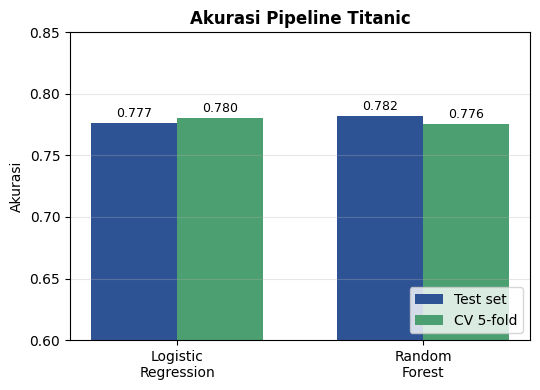

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

df = sns.load_dataset("titanic")
fitur_numerik = ["age", "fare"]
fitur_kategorikal = ["sex", "embarked"]
X = df[fitur_numerik + fitur_kategorikal]
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), fitur_numerik),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
     fitur_kategorikal),
])

models = {"Logistic\nRegression": LogisticRegression(max_iter=1000),
          "Random\nForest": RandomForestClassifier(n_estimators=200, random_state=42)}
acc_test, acc_cv = [], []
for nama, m in models.items():
    pipe = Pipeline([("preprocessing", preprocessor), ("model", m)])
    pipe.fit(X_train, y_train)
    acc_test.append(accuracy_score(y_test, pipe.predict(X_test)))
    acc_cv.append(cross_val_score(pipe, X, y, cv=5).mean())

x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(5.5, 4))
b1 = ax.bar(x - w/2, acc_test, w, label="Test set", color="#2E5395")
b2 = ax.bar(x + w/2, acc_cv, w, label="CV 5-fold", color="#4C9F70")
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f"{b.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(list(models.keys()))
ax.set_ylim(0.6, 0.85); ax.set_ylabel("Akurasi")
ax.set_title("Akurasi Pipeline Titanic", weight="bold")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.show()